#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

#### Load Dataset

In [3]:
df = pd.read_csv("winequality-red.csv")

#### Display First 5 Rows

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


#### Check Dataset Shape

In [6]:
df.shape

(1599, 12)

#### Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#### Check Data Types

In [10]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

#### Check Missing Values

In [11]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

#### Check Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(240)

#### Remove Duplicate Records

In [13]:
df = df.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [14]:
df.shape

(1359, 12)

#### Class Distribution

In [15]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

#### Plot Class Distribution

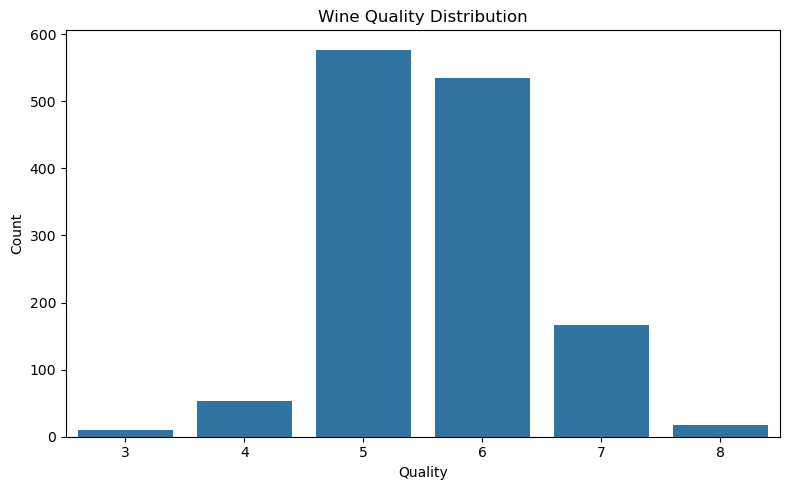

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="quality")

plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#### Descriptive Statistics

In [18]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#### Distribution Plots

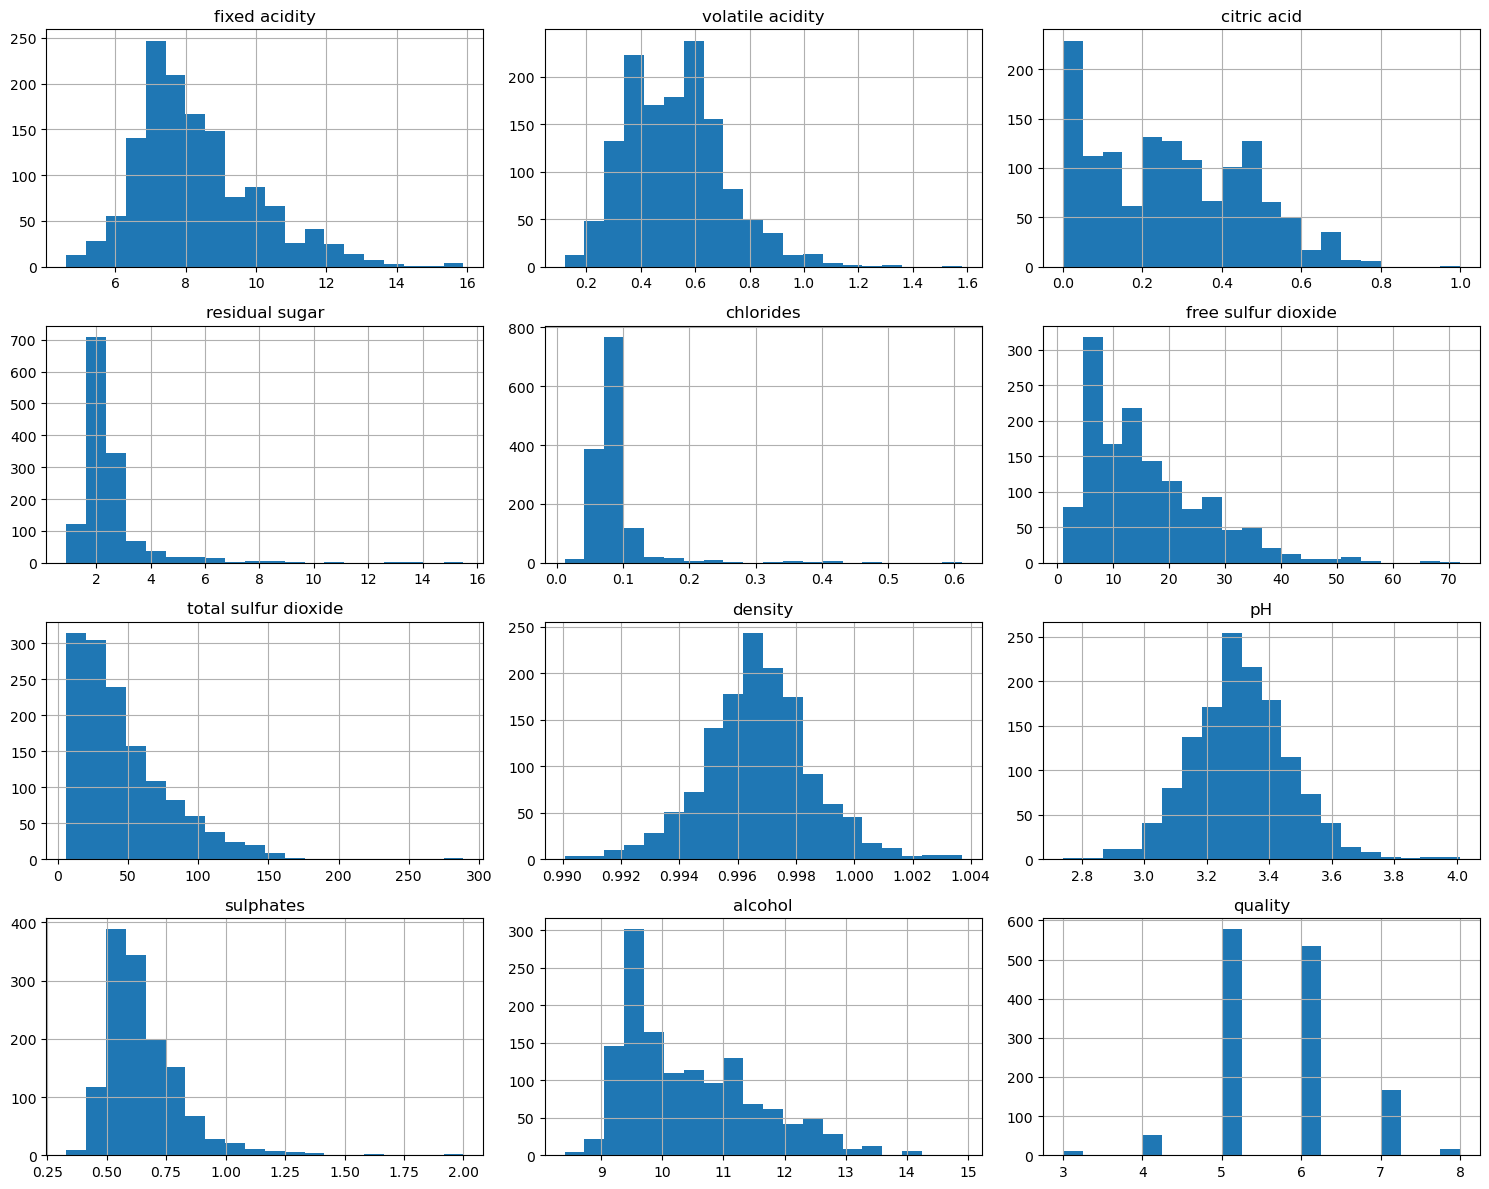

In [19]:
df.hist(figsize=(15,12), bins=20)

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

#### Correlation Heatmap

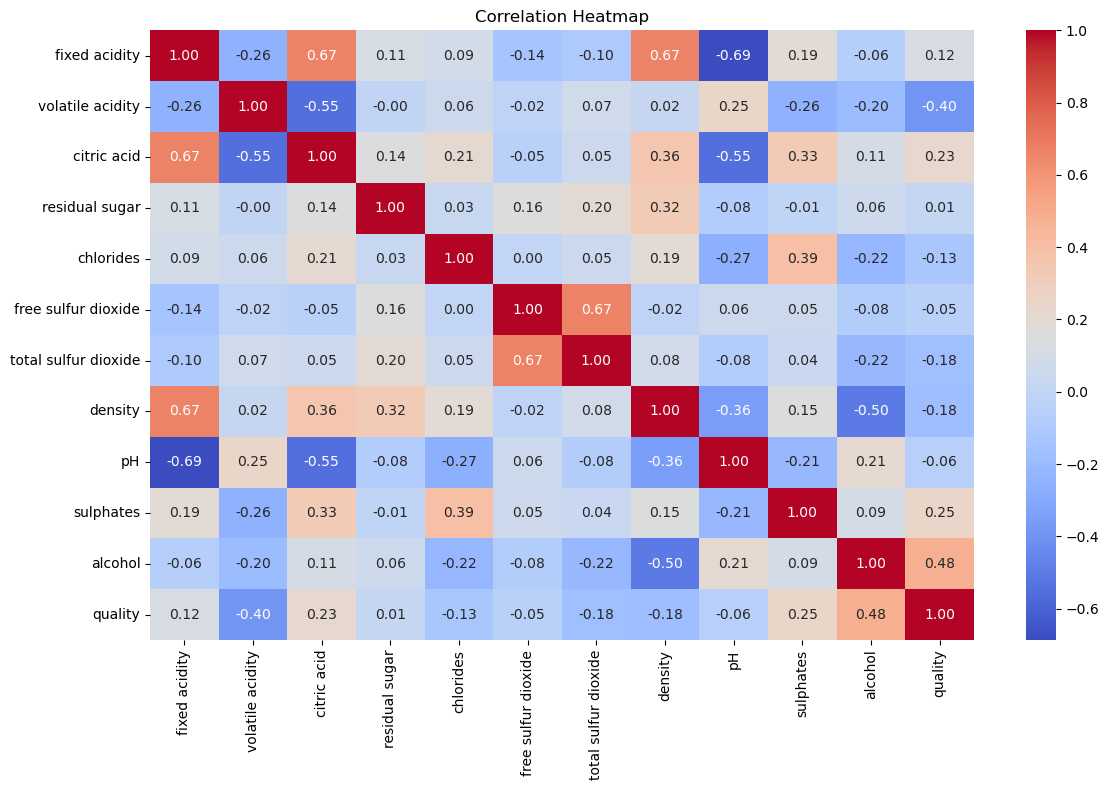

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

#### Features Correlated with Quality

In [22]:
df.corr()["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

#### Class Imbalance Discussion


The quality scores are not equally distributed.
Some classes have more samples, while others have fewer samples.
This class imbalance may affect the model's 
performance because the model can become biased toward the majority classes.
Using a stratified train-test split helps preserve
the class distribution in both training and testing datasets.

#### Feature Engineering

In [27]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

#### Check Updated Class Distribution

In [28]:
df["quality"].value_counts()

quality
0    1359
Name: count, dtype: int64

#### Feature Engineer
###### The quality scores were converted into two classes:

###### 0 = Bad Quality
###### 1 = Good Qualitying Discussion


#### Select Features and Target

In [32]:
X = df.drop("quality", axis=1)

y = df["quality"]

#### Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Check Dataset Shapes

In [63]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (1279, 11)
Testing Features  : (320, 11)
Training Target   : (1279,)
Testing Target    : (320,)


## Observation
The dataset has been converted into a binary classification problem.
An 80% training and 20% testing split was used.
Stratification preserved the class distribution in both datasets.

In [64]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# SGD
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)

# SVC
svc_model = SVC(random_state=42)
svc_model.fit(X_train, y_train)
svc_pred = svc_model.predict(X_test)

In [65]:
rf_accuracy = accuracy_score(y_test, rf_pred)
sgd_accuracy = accuracy_score(y_test, sgd_pred)
svc_accuracy = accuracy_score(y_test, svc_pred)

print("Random Forest Accuracy :", round(rf_accuracy, 4))
print("SGD Accuracy           :", round(sgd_accuracy, 4))
print("SVC Accuracy           :", round(svc_accuracy, 4))

Random Forest Accuracy : 0.8063
SGD Accuracy           : 0.6875
SVC Accuracy           : 0.6469


In [66]:
## Confusion Matrix - Random Forest

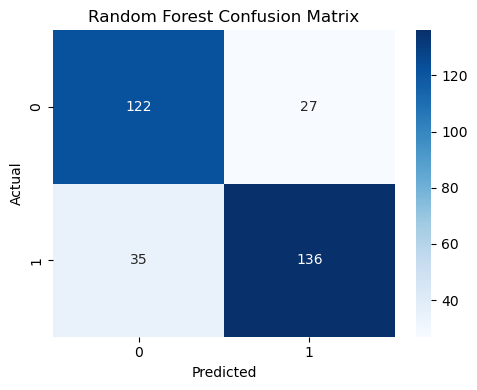

In [67]:
plt.figure(figsize=(5,4))

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [68]:
## Confusion Matrix - SGD

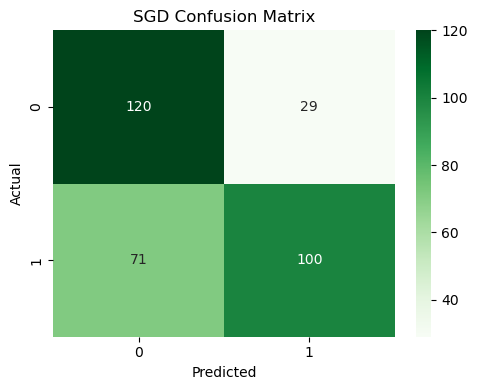

In [69]:
plt.figure(figsize=(5,4))

cm = confusion_matrix(y_test, sgd_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("sgd_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [70]:
## Confusion Matrix - SVC

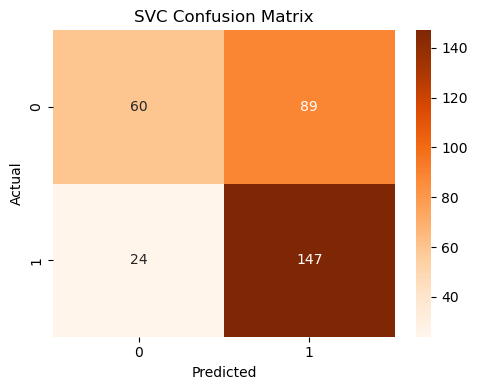

In [71]:
plt.figure(figsize=(5,4))

cm = confusion_matrix(y_test, svc_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("svc_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:
## Random Forest Feature Importance

In [74]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
10,alcohol,0.177181
9,sulphates,0.136640
1,volatile acidity,0.115503
6,total sulfur dioxide,0.099436
7,density,0.091812
0,fixed acidity,0.071066
4,chlorides,0.071027
8,pH,0.067446
2,citric acid,0.061122
5,free sulfur dioxide,0.056290


In [75]:
## Feature Importance Chart

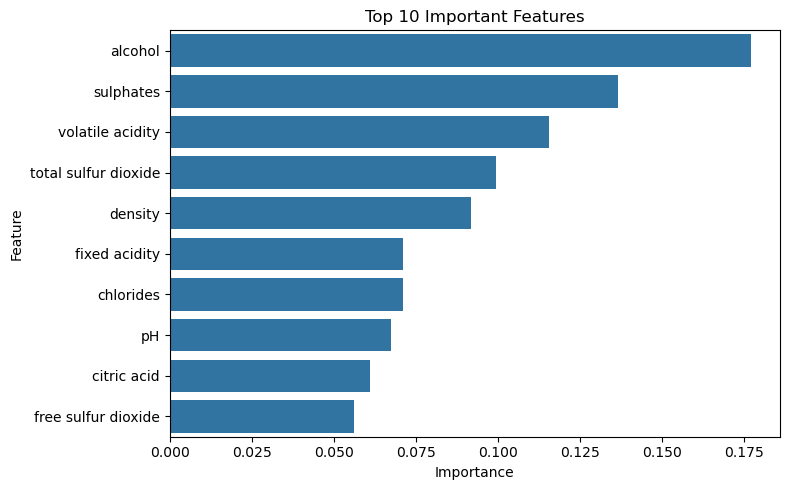

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
## Model Comparison

In [78]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [rf_accuracy, sgd_accuracy, svc_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest,0.806250
1,SGD,0.687500
2,SVC,0.646875


In [79]:
## Best Model

In [80]:
comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Random Forest,0.806250
1,SGD,0.687500
2,SVC,0.646875


## Conclusion
Three classification models were trained and evaluated.
Model performance was compared using Accuracy, Classification Report, and Confusion Matrix.
Random Forest Feature Importance identified the most influential chemical properties.
The model with the highest accuracy is the most suitable choice for deployment.